In [30]:
import torch
import json
from transformers import AutoTokenizer, AutoModelForCausalLM

# 1. Load model & tokenizer
model_name = "./models/big-qwen"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.eval()

# 2. Prepare input
input_text = """
You are a game command parser that converts natural language commands into DSL instructions.
Game State:
AIMED _ AT:
  type: Wall
  distance: 330.86
  interactable: yes

MONSTERS (count=0):

INVENTORY:
  current _ slot: 2
  weapons:
    - (1, Fist, 0)
    - (2, Pistol, 50)
Command:
Go press that switch ahead
"""

input_text2 = """
You are a game command parser that converts natural language commands into DSL instructions.
Game State:
AIMED_AT:
  type: Wall
  distance: 467.27
  interactable: yes

MONSTERS (count=2):
  - (MONSTER_0, Zombieman, 20, 228.43, 29.20, 3.37)
  - (MONSTER_1, Zombieman, 20, 218.13, 11.99, 4.33)

INVENTORY:
  current_slot: 3
  weapons:
    - (1, Fist, 0)
    - (2, Pistol, 186)
    - (3, Shotgun, 50)
Command:
Ignore the switch and gun down those soldiers
"""

inputs = tokenizer(input_text, return_tensors="pt")
input_ids = inputs["input_ids"]

# Storage for the gradient
embedding_grads = []

def backward_hook(grad):
    embedding_grads.append(grad)

# Get embeddings and register hook BEFORE forward pass
embedding_layer = model.get_input_embeddings()
embeddings = embedding_layer(input_ids)
embeddings.requires_grad_(True)
embeddings.register_hook(backward_hook)

target_token_id = tokenizer("ROTATE_TO_TARGET", add_special_tokens=False)["input_ids"][0]

outputs = model(inputs_embeds=embeddings)
logits = outputs.logits

last_logits = logits[0, -1, :]
log_probs = torch.nn.functional.log_softmax(last_logits, dim=-1)
loss = -log_probs[target_token_id]

loss.backward()

# Use the captured gradient
saliency = embedding_grads[0].norm(dim=-1).squeeze(0)

tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
tokens_map = dict()
for token, score in zip(tokens, saliency):
    print(f"{token}: {score.item():.4f}")
    tokens_map[token] = score.item()

json.dump(tokens_map, open("test.json", "w"))

Ċ: 9.5082
You: 1.0124
Ġare: 0.8861
Ġa: 3.9967
Ġgame: 1.2066
Ġcommand: 1.4277
Ġparser: 0.9071
Ġthat: 0.7652
Ġconverts: 0.7981
Ġnatural: 0.4517
Ġlanguage: 0.5878
Ġcommands: 1.2594
Ġinto: 1.2868
ĠDSL: 1.8858
Ġinstructions: 1.0530
.Ċ: 1.4133
Game: 2.3604
ĠState: 0.7934
:Ċ: 0.8747
AIM: 2.4997
ED: 0.5636
Ġ_: 0.4385
ĠAT: 0.4070
:Ċ: 0.4451
Ġ: 0.2607
Ġtype: 0.6912
:: 0.5133
ĠWall: 1.3413
Ċ: 0.7267
Ġ: 0.4443
Ġdistance: 1.9985
:: 1.1658
Ġ: 1.6500
3: 2.1966
3: 1.8827
0: 0.4813
.: 0.4883
8: 0.2977
6: 0.2153
Ċ: 0.6135
Ġ: 0.2709
Ġinteract: 1.4176
able: 0.4708
:: 0.5376
Ġyes: 1.1803
ĊĊ: 1.1297
MON: 1.0414
ST: 1.4521
ERS: 0.5074
Ġ(: 0.4608
count: 0.7506
=: 0.7422
0: 0.4359
):ĊĊ: 2.0487
IN: 3.1312
VENTORY: 0.7100
:Ċ: 0.6093
Ġ: 0.2212
Ġcurrent: 0.4439
Ġ_: 0.4065
Ġslot: 0.8613
:: 0.2266
Ġ: 0.1531
2: 0.2815
Ċ: 0.5399
Ġ: 0.2361
Ġweapons: 0.8234
:Ċ: 0.6069
ĠĠĠ: 0.5805
Ġ-: 0.6156
Ġ(: 0.7015
1: 0.4391
,: 0.6515
ĠFist: 2.0075
,: 0.6851
Ġ: 1.0760
0: 0.4986
)Ċ: 1.6552
ĠĠĠ: 1.3402
Ġ-: 0.6443
Ġ(: 0.7956
2: 0.6301
,

In [28]:
import math
raw = list(tokens_map.items())
# ── helpers ───────────────────────────────────────────────────────────────────

def clean(tok):
    """Strip BPE artefacts for display."""
    return tok.replace("Ġ", " ").replace("Ċ", "\n").replace("ĊĊ", "\n\n")

def normalize_log(scores):
    """Log-compress then min-max normalize to [0, 1]."""
    logged = [math.log1p(s) for s in scores]
    lo, hi = min(logged), max(logged)
    return [(v - lo) / (hi - lo) for v in logged]

def score_to_rgb(t):
    """
    Cool → warm fire palette:
      0.0  →  dark navy       ( 10,  20,  50)
      0.35 →  teal            ( 20, 120, 120)
      0.6  →  amber           (220, 140,  20)
      0.8  →  orange-red      (240,  70,  20)
      1.0  →  bright white-red(255, 240, 200)
    """
    stops = [
        (0.00, (10,  20,  50)),
        (0.35, (20, 120, 120)),
        (0.60, (220,140,  20)),
        (0.80, (240, 70,  20)),
        (1.00, (255,240, 200)),
    ]
    for i in range(len(stops) - 1):
        t0, c0 = stops[i]
        t1, c1 = stops[i + 1]
        if t <= t1:
            f = (t - t0) / (t1 - t0)
            r = int(c0[0] + f * (c1[0] - c0[0]))
            g = int(c0[1] + f * (c1[1] - c0[1]))
            b = int(c0[2] + f * (c1[2] - c0[2]))
            return r, g, b
    return stops[-1][1]

def luminance(r, g, b):
    return 0.299 * r + 0.587 * g + 0.114 * b

def ansi_bg(r, g, b):
    return f"\x1b[48;2;{r};{g};{b}m"

def ansi_fg(r, g, b):
    return f"\x1b[38;2;{r};{g};{b}m"

RESET   = "\x1b[0m"
BOLD    = "\x1b[1m"
DIM     = "\x1b[2m"

# ── render ────────────────────────────────────────────────────────────────────

scores  = [s for _, s in raw]
normed  = normalize_log(scores)

WIDTH   = 80

print()
print(f"  {BOLD}\x1b[38;2;180;160;255mSALIENCY MAP\x1b[0m"
      f"  {DIM}target → {RESET}{BOLD}\x1b[38;2;255;120;80mINTERACT{RESET}")

# colour-coded legend bar
print()
bar = ""
for i in range(WIDTH):
    t = i / (WIDTH - 1)
    r, g, b = score_to_rgb(t)
    bar += ansi_bg(r, g, b) + " "
bar += RESET
print(f"  {DIM}low{RESET}  {bar}  {DIM}high{RESET}")
print()

# separator
print(f"  \x1b[38;2;50;50;80m{'─' * (WIDTH + 6)}{RESET}")
print()

# main text — emit token by token
line_buf = "  "
line_len = 2

for (tok, score), t in zip(raw, normed):
    display = clean(tok)

    # handle newlines: flush current line first
    if "\n" in display:
        parts = display.split("\n")
        first = parts[0]
        if first:
            r, g, b = score_to_rgb(t)
            fg = (255, 255, 255) if luminance(r, g, b) < 128 else (10, 10, 20)
            line_buf += ansi_bg(r, g, b) + ansi_fg(*fg) + BOLD + first + RESET
        print(line_buf)
        for _ in parts[1:-1]:
            print()
        line_buf = "  "
        line_len = 2
        remainder = parts[-1]
        if remainder:
            r, g, b = score_to_rgb(t)
            fg = (255, 255, 255) if luminance(r, g, b) < 128 else (10, 10, 20)
            line_buf += ansi_bg(r, g, b) + ansi_fg(*fg) + BOLD + remainder + RESET
            line_len += len(remainder)
    else:
        r, g, b = score_to_rgb(t)
        fg = (255, 255, 255) if luminance(r, g, b) < 128 else (10, 10, 20)
        chunk = ansi_bg(r, g, b) + ansi_fg(*fg) + BOLD + display + RESET
        line_buf += chunk
        line_len += len(display)

if line_buf.strip():
    print(line_buf)

# ── score histogram ───────────────────────────────────────────────────────────
print()
print(f"  \x1b[38;2;50;50;80m{'─' * (WIDTH + 6)}{RESET}")
print(f"\n  {DIM}TOP TOKENS BY SALIENCY{RESET}\n")

top = sorted(zip(scores, [clean(t).strip() for t, _ in raw]),
             reverse=True)[:12]
max_s = top[0][0]

for s, tok in top:
    bar_w = int((s / max_s) * 40)
    t_norm = s / max_s
    r, g, b = score_to_rgb(t_norm)
    filled = ansi_fg(r, g, b) + ("█" * bar_w) + RESET
    empty  = DIM + ("░" * (40 - bar_w)) + RESET
    label  = f"{tok:<18}" if tok else f'{"(newline/space)":<18}'
    label  = label[:18]
    print(f"  {BOLD}{label}{RESET}  {filled}{empty}  {DIM}{s:.3f}{RESET}")

print()


  SALIENCY MAP  target → INTERACT

  low                                                                                    high

  ──────────────────────────────────────────────────────────────────────────────────────

  
  You are a game command parser that converts natural language commands into DSL instructions.
  Game State:
  AIMED_AT  type: Wall distance467.2 interactable yes

  MONSTERS (count=):
   -STER_0, Zombieman839)
  1)

  INVENTORY current_slot weapons    Fist Pistol Shotgun5CommandIgnore the switch and gun down those soldiers

  ──────────────────────────────────────────────────────────────────────────────────────

  TOP TOKENS BY SALIENCY

  soldiers            ████████████████████████████████████████  16.983
  Ignore              ████████████████████████░░░░░░░░░░░░░░░░  10.256
  the                 ███████████████░░░░░░░░░░░░░░░░░░░░░░░░░  6.491
  gun                 ██████████████░░░░░░░░░░░░░░░░░░░░░░░░░░  5.964
  those               ████████████░░░░░░░░░░░░░░░░░

In [24]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.colorbar import ColorbarBase
import math


def normalize_log(scores):
    logged = [math.log1p(s) for s in scores]
    lo, hi = min(logged), max(logged)
    return [(v - lo) / (hi - lo) for v in logged]

cmap = LinearSegmentedColormap.from_list("saliency", [
    "#0a1432", "#147878", "#dc8c14", "#f04614", "#fff0c8"
])

def fg_color(bg_rgba):
    r, g, b, _ = bg_rgba
    lum = 0.299 * r + 0.587 * g + 0.114 * b
    return "white" if lum < 0.5 else "#0a0a14"

scores = [s for _, s in raw]
normed = normalize_log(scores)

# Build lines: each entry is list of (text, norm_score)
# Key fix: decode each token fully, split on \n, never skip empty strings
# because empty strings between \n\n represent blank lines.
lines = [[]]
for (tok, _), t in zip(raw, normed):
    display = tok.replace("Ġ", " ").replace("Ċ", "\n")
    parts = display.split("\n")
    for i, part in enumerate(parts):
        if i > 0:
            lines.append([])   # real newline → new line
        if part != "":         # only skip truly empty, but we handle blank lines via the newline above
            lines[-1].append((part, t))
        # if part == "" and i > 0, it means \n\n => blank line already started, leave it empty

# strip only leading/trailing blank lines
while lines and not lines[0]:
    lines.pop(0)
while lines and not lines[-1]:
    lines.pop()

print(f"Number of lines: {len(lines)}")
for i, line in enumerate(lines):
    print(f"  Line {i}: {''.join(t for t,_ in line)!r}")

# --- Use renderer to measure actual text widths ---
FONT_SIZE = 11
FIG_W = 14  # inches, wide enough
LINE_H = 0.38  # inches per line
MARGIN_X = 0.3  # inches
MARGIN_TOP = 0.9
MARGIN_BOT = 0.5
PAD_X = 0.04  # inches padding each side of token

n_lines = len(lines)
fig_h = n_lines * LINE_H + MARGIN_TOP + MARGIN_BOT

fig, ax = plt.subplots(figsize=(FIG_W, fig_h))
fig.patch.set_facecolor("#0e0e18")
ax.set_facecolor("#0e0e18")
ax.axis("off")

# We'll work in inches using a transform
from matplotlib.transforms import Affine2D
import matplotlib.transforms as transforms

# Use data coords = inches directly
ax.set_xlim(0, FIG_W)
ax.set_ylim(0, fig_h)

# Title
ax.text(FIG_W/2, fig_h - 0.35, "SALIENCY MAP",
        fontsize=14, fontweight="bold", color="#a090ff",
        ha="center", va="center", fontfamily="monospace",
        transform=ax.transData)
ax.text(FIG_W/2, fig_h - 0.65, "target token → INTERACT",
        fontsize=9, color="#667", ha="center", va="center",
        fontfamily="monospace", transform=ax.transData)

# Render lines top to bottom
# We need accurate token widths. Use fig.canvas renderer.
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

for row_idx, line in enumerate(lines):
    # y center of this line in data (inch) coords
    y = fig_h - MARGIN_TOP - (row_idx + 0.5) * LINE_H
    x = MARGIN_X

    for text, t in line:
        bg = cmap(t)
        fg = fg_color(bg)

        # Place a dummy text to measure width
        tmp = ax.text(x, y, text, fontsize=FONT_SIZE, fontfamily="monospace",
                      color=fg, ha="left", va="center", zorder=3)
        fig.canvas.draw()
        bb = tmp.get_window_extent(renderer=renderer)
        # convert pixels to inches
        w_in = bb.width / fig.dpi
        h_in = bb.height / fig.dpi

        box_w = w_in + PAD_X * 2
        box_h = LINE_H * 0.82

        rect = mpatches.FancyBboxPatch(
            (x, y - box_h/2), box_w, box_h,
            boxstyle="round,pad=0.01",
            facecolor=bg, edgecolor="none", zorder=2,
            transform=ax.transData
        )
        ax.add_patch(rect)

        # Reposition text to be centered in box
        tmp.set_position((x + PAD_X, y))
        x += box_w

# Colorbar
cbar_ax = fig.add_axes([0.12, 0.01, 0.76, 0.025])
ColorbarBase(cbar_ax, cmap=cmap, norm=Normalize(0, 1), orientation="horizontal")
cbar_ax.set_xticks([0, 0.5, 1])
cbar_ax.set_xticklabels(["low saliency", "mid", "high saliency"], color="#aaa", fontsize=8)
cbar_ax.tick_params(length=0)

plt.savefig("./saliency_map.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
print("Saved.")

Number of lines: 8
  Line 0: 'You are a game command parser that converts natural language commands into DSL instructions.'
  Line 1: 'Game State:'
  Line 2: 'AIMED _ AT  type: Wall distance30.86 interactable yes'
  Line 3: ''
  Line 4: 'MONSTERS (count=):'
  Line 5: ''
  Line 6: 'INVENTORY current slot2 weapons    -1, Fist)'
  Line 7: ' Pistol5CommandGo press switch ahead'
Saved.


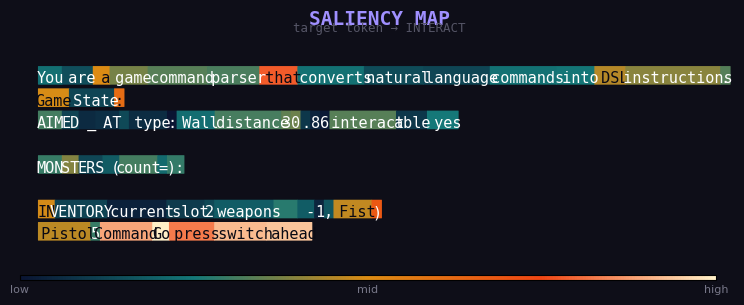

Saved → saliency_map.png


In [22]:
# ── helpers ───────────────────────────────────────────────────────────────────
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

def clean(tok):
    """Convert BPE special chars to readable text."""
    return tok.replace("Ġ", " ").replace("Ċ", "\n")

def normalize_log(scores):
    logged = [math.log1p(s) for s in scores]
    lo, hi = min(logged), max(logged)
    return [(v - lo) / (hi - lo) for v in logged]

# Fire colormap: navy → teal → amber → orange → white-hot
cmap = LinearSegmentedColormap.from_list("saliency", [
    "#0a1432", "#147878", "#dc8c14", "#f04614", "#fff0c8"
])

def tok_color(t):
    return cmap(t)

def fg_color(bg_rgba):
    r, g, b, _ = bg_rgba
    lum = 0.299 * r + 0.587 * g + 0.114 * b
    return "white" if lum < 0.5 else "#0a0a14"

# ── build word/line structure ─────────────────────────────────────────────────
# Expand each token into (display_text, score, norm) segments,
# respecting embedded newlines by splitting into sub-tokens.

scores = [s for _, s in raw]
normed = normalize_log(scores)

segments = []  # list of (text, norm_score) | "NEWLINE"
for (tok, _), t in zip(raw, normed):
    display = clean(tok)
    # split on newlines, inserting NEWLINE markers
    parts = display.split("\n")
    for i, part in enumerate(parts):
        if i > 0:
            segments.append("NEWLINE")
        if part:  # skip empty strings between consecutive newlines
            segments.append((part, t))

# Group segments into lines
lines = [[]]
for seg in segments:
    if seg == "NEWLINE":
        lines.append([])
    else:
        lines[-1].append(seg)

# Remove trailing empty lines
while lines and not lines[-1]:
    lines.pop()

# ── layout constants ──────────────────────────────────────────────────────────
FONT_SIZE   = 11
LINE_HEIGHT = 1.8   # in font-size units
CHAR_WIDTH  = 0.60  # approximate em width per character
PAD_X       = 0.18  # horizontal padding inside each token box (in chars)
PAD_Y       = 0.20  # vertical padding

# Figure width in characters, then convert to inches
MAX_LINE_CHARS = max((sum(len(t) for t, _ in line) for line in lines if line), default=40)
FIG_W_CHARS    = max(MAX_LINE_CHARS + 8, 60)
FIG_W_IN       = FIG_W_CHARS * CHAR_WIDTH * FONT_SIZE / 72  # pts → inches
N_LINES        = len(lines)
FIG_H_IN       = (N_LINES * LINE_HEIGHT + 4) * FONT_SIZE / 72

fig, ax = plt.subplots(figsize=(FIG_W_IN, FIG_H_IN))
ax.set_xlim(0, FIG_W_CHARS)
ax.set_ylim(0, N_LINES * LINE_HEIGHT + 3)
ax.axis("off")
fig.patch.set_facecolor("#0e0e18")

# ── title ─────────────────────────────────────────────────────────────────────
ax.text(
    FIG_W_CHARS / 2, N_LINES * LINE_HEIGHT + 2.4,
    "SALIENCY MAP", fontsize=14, fontweight="bold",
    color="#a090ff", ha="center", va="center",
    fontfamily="monospace"
)
ax.text(
    FIG_W_CHARS / 2, N_LINES * LINE_HEIGHT + 1.7,
    "target token → INTERACT", fontsize=9,
    color="#556", ha="center", va="center",
    fontfamily="monospace"
)

# ── colorbar legend ───────────────────────────────────────────────────────────
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
cbar_ax = fig.add_axes([0.12, 0.01, 0.76, 0.018])
ColorbarBase(cbar_ax, cmap=cmap, norm=Normalize(0, 1), orientation="horizontal")
cbar_ax.set_xticks([0, 0.5, 1])
cbar_ax.set_xticklabels(["low", "mid", "high"], color="#778", fontsize=8)
cbar_ax.tick_params(length=0)

# ── render tokens ─────────────────────────────────────────────────────────────
MARGIN_X = 2.0

for row_idx, line in enumerate(lines):
    # lines are rendered top-to-bottom
    y = (N_LINES - 1 - row_idx) * LINE_HEIGHT + 1.2
    x = MARGIN_X

    for text, t in line:
        bg = tok_color(t)
        fg = fg_color(bg)
        w  = len(text) + PAD_X * 2

        # background rectangle
        rect = mpatches.FancyBboxPatch(
            (x, y - 0.45), w, LINE_HEIGHT * 0.78,
            boxstyle="round,pad=0.05",
            facecolor=bg, edgecolor="none",
            zorder=2
        )
        ax.add_patch(rect)

        # token text
        ax.text(
            x + w / 2, y,
            text,
            fontsize=FONT_SIZE, fontfamily="monospace",
            color=fg, ha="center", va="center",
            zorder=3
        )

        x += w

plt.savefig("saliency_map.png", dpi=1650, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → saliency_map.png")

In [14]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def plot_saliency_text(tokens_map, title="Saliency Map", vmin=None, vmax=None):
    tokens = list(tokens_map.keys())
    scores = np.array(list(tokens_map.values()))

    # Normalize consistently (important if comparing multiple actions)
    if vmin is None:
        vmin = scores.min()
    if vmax is None:
        vmax = scores.max()

    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.cm.Reds

    fig, ax = plt.subplots(figsize=(14, 2))
    ax.axis("off")

    x = 0.01
    y = 0.5

    for token, score in zip(tokens, scores):
        color = cmap(norm(score))
        text = ax.text(
            x, y, token + " ",
            fontsize=14,
            bbox=dict(facecolor=color, edgecolor='none', boxstyle='round,pad=0.3')
        )
        fig.canvas.draw()
        bbox = text.get_window_extent()
        x += bbox.width / fig.dpi / fig.get_size_inches()[0]

    plt.title(title, fontsize=16)
    plt.show()

    return vmin, vmax  # return scale so you can reuse it

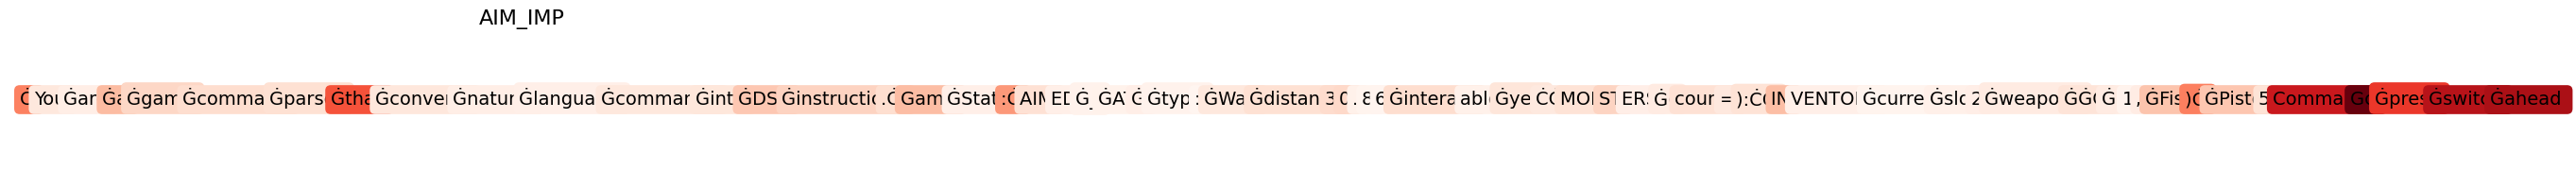

In [17]:
vmin, vmax = plot_saliency_text(tokens_map, title="AIM_IMP")

In [26]:
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.colorbar import ColorbarBase

# ── your data ─────────────────────────────────────────────────────────────────
raw = [
    ("Ċ", 9.3700), ("You", 0.9917), ("Ġare", 0.6642), ("Ġa", 2.6743),
    ("Ġgame", 1.7618), ("Ġcommand", 1.5232), ("Ġparser", 1.4349),
    ("Ġthat", 1.1326), ("Ġconverts", 1.0163), ("Ġnatural", 0.6306),
    ("Ġlanguage", 0.5776), ("Ġcommands", 1.0123), ("Ġinto", 1.0735),
    ("ĠDSL", 2.2887), ("Ġinstructions", 1.9027), (".Ċ", 1.5031),
    ("Game", 2.6094), ("ĠState", 0.5760), (":Ċ", 0.5200), ("AIM", 1.3877),
    ("ED", 0.5700), ("Ġ_", 0.4030), ("ĠAT", 0.3966), (":Ċ", 0.4494),
    ("Ġ", 0.2960), ("Ġtype", 0.3754), (":", 0.3437), ("ĠWall", 0.9813),
    ("Ċ", 0.4795), ("Ġ", 0.3880), ("Ġdistance", 1.4191), (":", 0.6436),
    ("Ġ", 1.1389), ("3", 2.2544), ("3", 1.5903), ("0", 0.4510),
    (".", 0.4633), ("8", 0.3132), ("6", 0.2451), ("Ċ", 0.4243),
    ("Ġ", 0.2318), ("Ġinteract", 1.5291), ("able", 0.4575), (":", 0.4523),
    ("Ġyes", 1.0958), ("ĊĊ", 0.9185), ("MON", 1.3069), ("ST", 1.8493),
    ("ERS", 0.5881), ("Ġ(", 0.5795), ("count", 1.3932), ("=", 0.9492),
    ("0", 0.6569), ("):ĊĊ", 1.2966), ("IN", 2.5800), ("VENTORY", 0.5682),
    (":Ċ", 0.4841), ("Ġ", 0.2549), ("Ġcurrent", 0.2894), ("Ġ_", 0.3640),
    ("Ġslot", 0.5029), (":", 0.1995), ("Ġ", 0.1376), ("2", 0.2418),
    ("Ċ", 0.3264), ("Ġ", 0.1468), ("Ġweapons", 0.8060), (":Ċ", 0.4063),
    ("ĠĠĠ", 0.5621), ("Ġ-", 0.4679), ("Ġ(", 0.7752), ("1", 0.3215),
    (",", 0.5075), ("ĠFist", 2.3913), (",", 0.6001), ("Ġ", 0.6442),
    ("0", 0.5252), (")Ċ", 1.3549), ("ĠĠĠ", 1.2210), ("Ġ-", 0.8046),
    ("Ġ(", 0.7843), ("2", 0.6031), (",", 0.6377), ("ĠPistol", 2.3364),
    (",", 0.7396), ("Ġ", 0.6239), ("5", 1.3240), ("0", 1.6838),
    (")Ċ", 4.5492), ("Command", 7.7118), (":Ċ", 3.7370), ("Go", 10.1463),
    ("Ġpress", 6.5498), ("Ġthat", 5.8203), ("Ġswitch", 8.3024),
    ("Ġahead", 8.6834), ("Ċ", 4.4665),
]

# ── helpers ───────────────────────────────────────────────────────────────────

def clean(tok):
    return tok.replace("Ġ", " ").replace("Ċ", "\n")

def normalize_log(scores):
    logged = [math.log1p(s) for s in scores]
    lo, hi = min(logged), max(logged)
    return [(v - lo) / (hi - lo) for v in logged]

cmap = LinearSegmentedColormap.from_list("saliency", [
    "#0a1432", "#147878", "#dc8c14", "#f04614", "#fff0c8"
])

def fg_color(bg_rgba):
    r, g, b, _ = bg_rgba
    return "white" if (0.299*r + 0.587*g + 0.114*b) < 0.5 else "#0a0a14"

# ── expand tokens into (text, norm) segments with explicit NEWLINE markers ────
scores = [s for _, s in raw]
normed = normalize_log(scores)

segments = []
for (tok, _), t in zip(raw, normed):
    parts = clean(tok).split("\n")
    for i, part in enumerate(parts):
        if i > 0:
            segments.append("NEWLINE")
        # Always append, even if part == "" — empty string = whitespace-only token
        # but we DO want to skip truly empty splits that add phantom blank lines,
        # EXCEPT when the original token was purely a newline.
        if part != "" or len(parts) == 1:
            segments.append((part, t))

# Group into lines — skip lines that are entirely empty-string tokens
lines = [[]]
for seg in segments:
    if seg == "NEWLINE":
        lines.append([])
    else:
        lines[-1].append(seg)

# ── figure setup (generous width; height auto-scales) ────────────────────────
FONT_SIZE   = 11
LINE_HEIGHT = 22      # pixels between baselines
PAD_X       = 4       # horizontal pixel padding inside each token box
PAD_Y       = 3       # vertical pixel padding
DPI         = 150
FIG_W_IN    = 12

fig, ax = plt.subplots(figsize=(FIG_W_IN, 4))  # height adjusted below
ax.axis("off")
fig.patch.set_facecolor("#0e0e18")

# We need the renderer to measure text — draw a dummy render pass first
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

def measure_text_px(text, fontsize):
    """Return the rendered width of `text` in pixels using a scratch Text."""
    t = ax.text(0, 0, text, fontsize=fontsize, fontfamily="monospace")
    bb = t.get_window_extent(renderer=renderer)
    t.remove()
    return bb.width

# Pre-measure all unique token texts
unique_texts = set(text for seg in segments if seg != "NEWLINE" for text, _ in [seg])
text_widths = {t: measure_text_px(t, FONT_SIZE) + PAD_X * 2 for t in unique_texts}
# Ensure single-space tokens aren't collapsed to zero
SPACE_W = measure_text_px(" ", FONT_SIZE) + PAD_X * 2

def tok_w(text):
    if text == "":
        return 0
    return max(text_widths.get(text, SPACE_W), SPACE_W)

# ── compute total figure height now that we know line count ──────────────────
N_LINES     = len(lines)
MARGIN_TOP  = 60    # px for title
MARGIN_BOT  = 40    # px for colorbar
MARGIN_LR   = 20
FIG_H_PX    = MARGIN_TOP + N_LINES * LINE_HEIGHT + LINE_HEIGHT + MARGIN_BOT
FIG_H_IN    = FIG_H_PX / DPI

fig.set_size_inches(FIG_W_IN, FIG_H_IN)
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

# ── coordinate helpers (work in pixels via ax.transData = identity in px) ────
# Use a simple pixel-based axes that covers the whole figure
ax.set_xlim(0, FIG_W_IN * DPI)
ax.set_ylim(0, FIG_H_PX)

def draw_token(cx, cy, text, t):
    """Draw one token: background rect + text, centred at (cx, cy) in px."""
    bg   = cmap(t)
    fg   = fg_color(bg)
    w    = tok_w(text)
    h    = LINE_HEIGHT - 2
    x0   = cx - w / 2
    y0   = cy - h / 2

    rect = mpatches.FancyBboxPatch(
        (x0, y0), w, h,
        boxstyle="round,pad=1.5",
        facecolor=bg, edgecolor="none",
        transform=ax.transData, zorder=2,
        clip_on=False
    )
    ax.add_patch(rect)
    ax.text(
        cx, cy, text,
        fontsize=FONT_SIZE, fontfamily="monospace",
        color=fg, ha="center", va="center",
        transform=ax.transData, zorder=3,
        clip_on=False
    )

# ── title ─────────────────────────────────────────────────────────────────────
mid_x = FIG_W_IN * DPI / 2
ax.text(mid_x, FIG_H_PX - 18, "SALIENCY MAP",
        fontsize=13, fontweight="bold", color="#a090ff",
        ha="center", va="center", fontfamily="monospace",
        transform=ax.transData)
ax.text(mid_x, FIG_H_PX - 36, "target token → INTERACT",
        fontsize=9, color="#667", ha="center", va="center",
        fontfamily="monospace", transform=ax.transData)

# ── render lines top → bottom ─────────────────────────────────────────────────
for row_idx, line in enumerate(lines):
    y  = FIG_H_PX - MARGIN_TOP - row_idx * LINE_HEIGHT - LINE_HEIGHT // 2
    x  = MARGIN_LR

    for text, t in line:
        if text == "":
            continue
        w  = tok_w(text)
        cx = x + w / 2
        draw_token(cx, y, text, t)
        x += w

# ── colorbar ──────────────────────────────────────────────────────────────────
cbar_ax = fig.add_axes([0.1, 0.01, 0.8, 0.025])
ColorbarBase(cbar_ax, cmap=cmap, norm=Normalize(0, 1), orientation="horizontal")
cbar_ax.set_xticks([0, 0.5, 1])
cbar_ax.set_xticklabels(["low saliency", "mid", "high"], color="#889", fontsize=8)
cbar_ax.tick_params(length=0)

plt.savefig("saliency_map.png", dpi=DPI, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Saved → saliency_map.png")

Saved → saliency_map.png


C:\Users\Filippo Corti\AppData\Local\Temp\ipykernel_40420\1427492666.py:187: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
